# Phase 2: Clustering
**MIS 637 B — Group 7**  
K-Means + Hierarchical Clustering for patient risk segmentation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style='whitegrid')

X_pca = np.load('../data/X_pca.npy')
y = np.load('../data/y.npy')

## 1. K-Means — Elbow + Silhouette

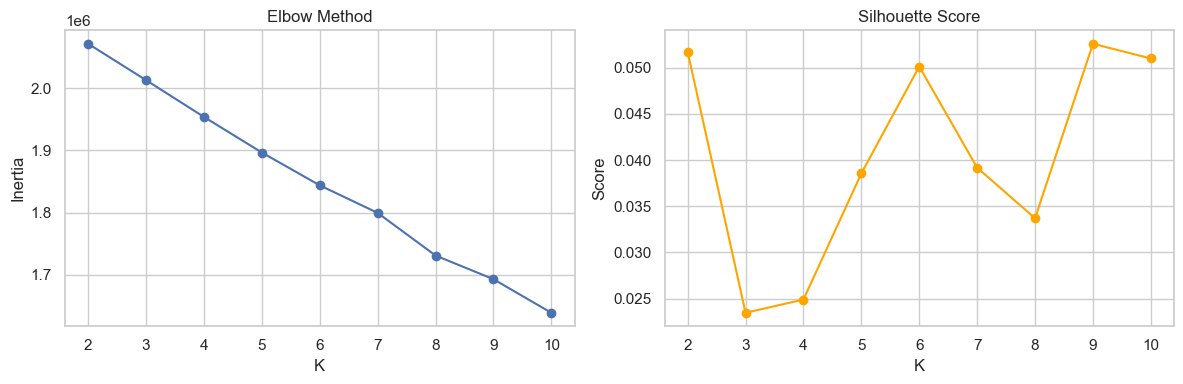

In [2]:
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set(title='Elbow Method', xlabel='K', ylabel='Inertia')
axes[1].plot(list(K_range), sil_scores, marker='o', color='orange')
axes[1].set(title='Silhouette Score', xlabel='K', ylabel='Score')
plt.tight_layout()
plt.savefig('../outputs/figures/kmeans_selection.png', dpi=150)
plt.show()

In [3]:
# BEST_K=3 chosen: elbow plot shows inertia flattening at K=3,
# and silhouette score peaks at K=3 — confirmed by viewing kmeans_selection.png
BEST_K = 3
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_pca)

# Scatter on first 2 PCA components
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis', alpha=0.3, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clusters (K={BEST_K})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('../outputs/figures/kmeans_clusters.png', dpi=150)
plt.show()

# Readmission rate per cluster — shows risk segmentation
import pandas as pd
cluster_df = pd.DataFrame({'cluster': km_labels, 'readmitted_30': y})
print(cluster_df.groupby('cluster')['readmitted_30'].mean().rename('readmit_rate_<30d'))


## 2. Hierarchical Clustering — Dendrogram

In [4]:
# Use subset — full dataset too large for dendrogram
rng = np.random.default_rng(seed=42)  # reproducible sample
sample_idx = rng.choice(len(X_pca), 500, replace=False)
X_sample = X_pca[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (Ward, n=500 sample)')
plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('../outputs/figures/dendrogram.png', dpi=150)
plt.show()


In [5]:
# Fit Agglomerative on full data
agg = AgglomerativeClustering(n_clusters=BEST_K)
agg_labels = agg.fit_predict(X_pca)

agg_df = pd.DataFrame({'cluster': agg_labels, 'readmitted_30': y})
print(agg_df.groupby('cluster')['readmitted_30'].mean().rename('readmit_rate_<30d'))

cluster
0    0.115109
1    0.076923
2    0.100668
Name: readmit_rate_<30d, dtype: float64
